# Лабораторная работа 3 #

## Выполнила: Иванова Дарья Сергеевна БПМ-23-ПО-2 

Задача: Взять несколько статей из канала "Исторические напёрстки" в дзене и посчитать количество гласных букв, точек и восклицательных знаков и впоросительных знаков, а в конце выполнить кластеризацию с помощью сети кохонена

In [1]:
!pip install minisom


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import numpy as np
import pandas as pd
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Загрузка данных

In [34]:
df = pd.read_csv('historycal_texts(1).csv', header=None)

text_column = 0
df[text_column] = df[text_column].fillna("").astype(str)
print(df.head())

                                                   0
0  Неугомонные. Чудесную новость на лопате принес...
1  А к имеющимся в JEF скоттам, голландцам, сканд...
2  На недоумённые вопросы «а как же НАТО», скоттс...
3  Как водится, риторические вопросы. В 2014-м, п...
4  Четыре года. Решив, что будет «действовать сам...


Подсчет

In [35]:
vowels = "аеёиоуыэюяАЕЁИОУЫЭЮЯ"

def count_vowels(text):
    return sum(1 for ch in text if ch in vowels)

def safe_len(text):
    return len(text) if len(text) > 0 else 1

Добавляю признаки 

In [36]:
df["total_chars"] = df[text_column].apply(len)

df["vowel_count"] = df[text_column].apply(count_vowels)
df["dot_count"] = df[text_column].str.count(r"\.")
df["excl_count"] = df[text_column].str.count(r"!")
df["quest_count"] = df[text_column].str.count(r"\?")

Нормализация

In [37]:
df["vowel_ratio"] = df["vowel_count"] / df["total_chars"].replace(0, 1)
df["dot_ratio"] = df["dot_count"] / df["total_chars"].replace(0, 1)
df["excl_ratio"] = df["excl_count"] / df["total_chars"].replace(0, 1)
df["quest_ratio"] = df["quest_count"] / df["total_chars"].replace(0, 1)

print(df[["vowel_ratio", "dot_ratio", "excl_ratio", "quest_ratio"]].head())

   vowel_ratio  dot_ratio  excl_ratio  quest_ratio
0     0.328395   0.007407         0.0          0.0
1     0.361858   0.007335         0.0          0.0
2     0.352078   0.004890         0.0          0.0
3     0.341373   0.009276         0.0          0.0
4     0.345263   0.010526         0.0          0.0


Подготовка данных к SOM

In [38]:
features = df[["vowel_ratio", "dot_ratio", "excl_ratio", "quest_ratio"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

Cеть Кохонена

In [39]:
som = MiniSom(
    x=5, 
    y=5, 
    input_len=4,
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

som.random_weights_init(X_scaled)
som.train_random(X_scaled, 1000)

Кластеры

In [41]:
winners = [som.winner(x) for x in X_scaled]

df["cluster"] = [w[0]*5 + w[1] for w in winners]

print(df[[text_column, "cluster"]].head())

                                                   0  cluster
0  Неугомонные. Чудесную новость на лопате принес...       24
1  А к имеющимся в JEF скоттам, голландцам, сканд...        9
2  На недоумённые вопросы «а как же НАТО», скоттс...       22
3  Как водится, риторические вопросы. В 2014-м, п...       19
4  Четыре года. Решив, что будет «действовать сам...       19


Визуализация

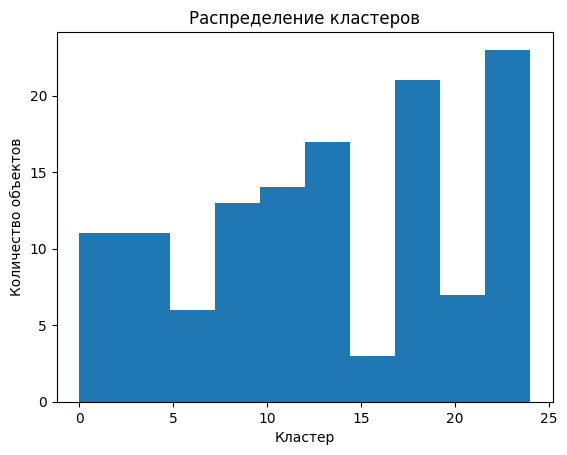

In [42]:
plt.figure()
plt.hist(cluster_labels)
plt.title('Распределение кластеров')
plt.xlabel('Кластер')
plt.ylabel('Количество объектов')
plt.show()